# 实验分析测试 - 2022世界杯决赛

本notebook用于测试实验分析功能在2022世界杯决赛数据上的运行。

**比赛**: 阿根廷 vs 法国 (Game ID: 10517)

**测试内容**:
1. 数据加载和基本统计
2. 网格/区域分析
3. 防守组合分析
4. 球员表现评估
5. 统计分析和可视化

## 1. 导入库和配置

In [1]:
import os
import gc
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from mplsoccer import Pitch

# 添加父目录到Python路径（用于导入项目模块）
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    print(f"✓ 已添加父目录到Python路径: {parent_dir}")

import convert_tracking as ct

# 配置matplotlib中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

print("✓ 库导入成功")
print("✓ 中文字体配置完成")

✓ 已添加父目录到Python路径: e:\JerryWu\Master\SoccerAnalytics\TrackingData_literature_code\Evaluating Defensive Influence Using GATs-main (modified for 2022 WC)
✓ 库导入成功
✓ 中文字体配置完成


## 2. 配置参数

In [2]:
# 固定使用决赛数据
GAME_ID = '10517'
DATA_DIR = f'Data/{GAME_ID}'
RESULTS_DIR = f'results/player_eval_{GAME_ID}'
XT_GRID_PATH = 'xT_grid.csv'

print(f"配置完成: 比赛ID={GAME_ID}")
print(f"数据目录: {DATA_DIR}")
print(f"结果目录: {RESULTS_DIR}")

配置完成: 比赛ID=10517
数据目录: Data/10517
结果目录: results/player_eval_10517


## 3. 加载元数据和比赛数据

In [3]:
# 加载元数据
metadata = ct.get_metadata(GAME_ID)
home_team_name = metadata[2]
away_team_name = metadata[3]
rosters_home = metadata[5]
rosters_away = metadata[6]

print(f"比赛: {home_team_name} vs {away_team_name}")
print(f"主队阵容: {len(rosters_home)} 人")
print(f"客队阵容: {len(rosters_away)} 人")

比赛: Argentina vs France
主队阵容: 26 人
客队阵容: 24 人


## 4. 创建球员位置映射

In [4]:
# 加载球员数据以获取位置信息
players_df = pd.read_csv(f'{DATA_DIR}/players_{GAME_ID}.csv')

# 创建球员位置字典
player_position_dict = dict(zip(players_df['playerName'], players_df['playerPos']))

print(f"✓ 创建了 {len(player_position_dict)} 个球员的位置映射")
print(f"位置类型: {players_df['playerPos'].unique()}")

✓ 创建了 35 个球员的位置映射
位置类型: ['CM' 'AM' 'RCB' 'LCB' 'GK' 'RB' 'CF' 'LW' 'RW' 'LB' 'DM']


## 5. 加载球员评估结果

In [5]:
# 加载球员评估结果
results_file = f'{RESULTS_DIR}/{GAME_ID}_defender_performance.csv'

if os.path.exists(results_file):
    results_model1_df = pd.read_csv(results_file)
    print(f"✓ 加载了 {len(results_model1_df)} 条评估记录")
    print(f"\n数据列: {list(results_model1_df.columns)}")
    print(f"\n数据预览:")
    print(results_model1_df.head())
else:
    print(f"❌ 未找到结果文件: {results_file}")
    print("请先运行 test_player_eval_final.ipynb 生成评估结果")
    results_model1_df = None

✓ 加载了 5203 条评估记录

数据列: ['graph_index', 'Attacker', 'Defender', 'match_id', 'Def_Distance', 'Def_Attention', 'Def_Influence', 'Def_Rel_Influence (%)', 'Att_Threat', 'Total_Perf']

数据预览:
   graph_index             Attacker             Defender  match_id  \
0            0        Adrien Rabiot  Alexis Mac Allister     10517   
1            0    Antoine Griezmann  Alexis Mac Allister     10517   
2            0  Aurélien Tchouaméni  Alexis Mac Allister     10517   
3            0      Dayot Upamecano  Alexis Mac Allister     10517   
4            0          Hugo Lloris  Alexis Mac Allister     10517   

   Def_Distance  Def_Attention  Def_Influence  Def_Rel_Influence (%)  \
0     20.665522       0.043729       0.005365               7.009895   
1     10.554369       0.043949       0.005196               7.130032   
2     20.473899       0.043959       0.005565               7.090869   
3     33.757803       0.043641       0.004873               7.026586   
4     45.495774       0.043480    

## 6. 加载事件数据

In [6]:
# 加载事件数据
events_df = pd.read_csv(f'{DATA_DIR}/events_{GAME_ID}.csv')
events_df['match_id'] = int(GAME_ID)

print(f"✓ 加载了 {len(events_df)} 个事件")
print(f"\n事件类型: {events_df['eventType'].unique()}")
if 'possessionEventType' in events_df.columns:
    print(f"控球事件类型: {events_df['possessionEventType'].unique()}")

✓ 加载了 1700 个事件

事件类型: ['FIRSTKICKOFF' 'OTB' 'SECONDKICKOFF' 'OUT' 'THIRDKICKOFF' 'FOURTHKICKOFF']
控球事件类型: ['PA' 'CH' 'BC' 'CR' 'CL' 'RE' 'SH']


## 7. 基本统计分析

In [7]:
if results_model1_df is not None:
    # 添加球员位置信息
    results_model1_df['defender_pos'] = results_model1_df['Defender'].map(player_position_dict)
    results_model1_df['attacker_pos'] = results_model1_df['Attacker'].map(player_position_dict)
    
    # 计算相对表现
    avg_performance = results_model1_df.groupby('graph_index')['Total_Perf'].transform('mean')
    results_model1_df['relative_performance'] = results_model1_df['Total_Perf'] - avg_performance
    
    print("✓ 添加了位置信息和相对表现指标")
    print(f"\n防守球员位置分布:")
    print(results_model1_df['defender_pos'].value_counts())
    print(f"\n进攻球员位置分布:")
    print(results_model1_df['attacker_pos'].value_counts())

✓ 添加了位置信息和相对表现指标

防守球员位置分布:
CM     1122
RCB     473
GK      473
CF      473
RW      473
RB      473
LB      473
LCB     473
LW      473
AM      297
Name: defender_pos, dtype: int64

进攻球员位置分布:
CM     1243
LCB     473
GK      473
RB      473
LW      473
CF      473
RW      473
RCB     473
LB      473
AM      176
Name: attacker_pos, dtype: int64


## 8. 网格区域分析

In [8]:
def assign_grid_cell(x, y, pitch_length=105, pitch_width=68, grid_length=6, grid_width=4):
    """将坐标分配到网格单元"""
    cell_length = pitch_length / grid_length
    cell_width = pitch_width / grid_width
    
    x_cell = int(np.floor(x / cell_length)) + 1
    y_cell = int(np.floor(y / cell_width)) + 1
    
    x_cell = min(max(x_cell, 1), grid_length)
    y_cell = min(max(y_cell, 1), grid_width)
    
    grid_cell = (y_cell - 1) * grid_length + x_cell
    return grid_cell - 1

print("✓ 网格分配函数定义完成")

✓ 网格分配函数定义完成


In [9]:
if results_model1_df is not None:
    # 加载球的位置数据
    balls_df = pd.read_csv(f'{DATA_DIR}/balls_{GAME_ID}.csv')
    
    # 为每个记录添加球的位置（通过graph_index关联）
    # 注意：这里需要根据实际数据结构调整
    results_model1_df_unique = results_model1_df.drop_duplicates(subset=['graph_index', 'Defender'])
    
    print(f"✓ 创建了 {len(results_model1_df_unique)} 条唯一记录用于网格分析")

✓ 创建了 473 条唯一记录用于网格分析


## 9. 防守球员表现排名

In [10]:
if results_model1_df is not None:
    # 按防守球员分组统计
    defender_stats = results_model1_df.groupby('Defender').agg({
        'Total_Perf': ['mean', 'sum', 'count'],
        'Def_Influence': 'mean',
        'Def_Attention': 'mean',
        'Def_Distance': 'mean',
        'defender_pos': 'first'
    }).round(4)
    
    defender_stats.columns = ['_'.join(col).strip() for col in defender_stats.columns.values]
    defender_stats = defender_stats.sort_values('Total_Perf_mean', ascending=False)
    
    print("防守球员表现排名 (Top 10):")
    print(defender_stats.head(10))
    
    print("\n防守影响力最大 (Top 10):")
    print(defender_stats.sort_values('Def_Influence_mean').head(10)[['Def_Influence_mean', 'defender_pos_first']])

防守球员表现排名 (Top 10):
                     Total_Perf_mean  Total_Perf_sum  Total_Perf_count  \
Defender                                                                 
Emiliano Martínez             2.7307        480.5978               176   
Nicolás Otamendi              2.6482        466.0811               176   
Ángel Di María                2.5983        457.2930               176   
Cristian Romero               2.5914        456.0848               176   
Alexis Mac Allister           2.5799        454.0677               176   
Enzo Fernandez                2.5775        453.6411               176   
Nicolas Tagliafico            2.5557        449.7969               176   
Julian Alvarez                2.5084        441.4820               176   
Rodrigo de Paul               2.5035        440.6185               176   
Nahuel Molina                 2.4872        437.7488               176   

                     Def_Influence_mean  Def_Attention_mean  \
Defender                     

## 10. 按位置分析

按位置统计防守表现:
              Total_Perf_mean  Total_Perf_std  Total_Perf_count
defender_pos                                                   
AM                     2.1544          0.5260                27
CF                     2.2957          0.5559                43
CM                     2.3690          0.5805               102
GK                     2.4766          0.6329                43
LB                     2.3516          0.5848                43
LCB                    2.3902          0.6232                43
LW                     2.3600          0.5968                43
RB                     2.2732          0.5680                43
RCB                    2.3553          0.5960                43
RW                     2.2428          0.5653                43


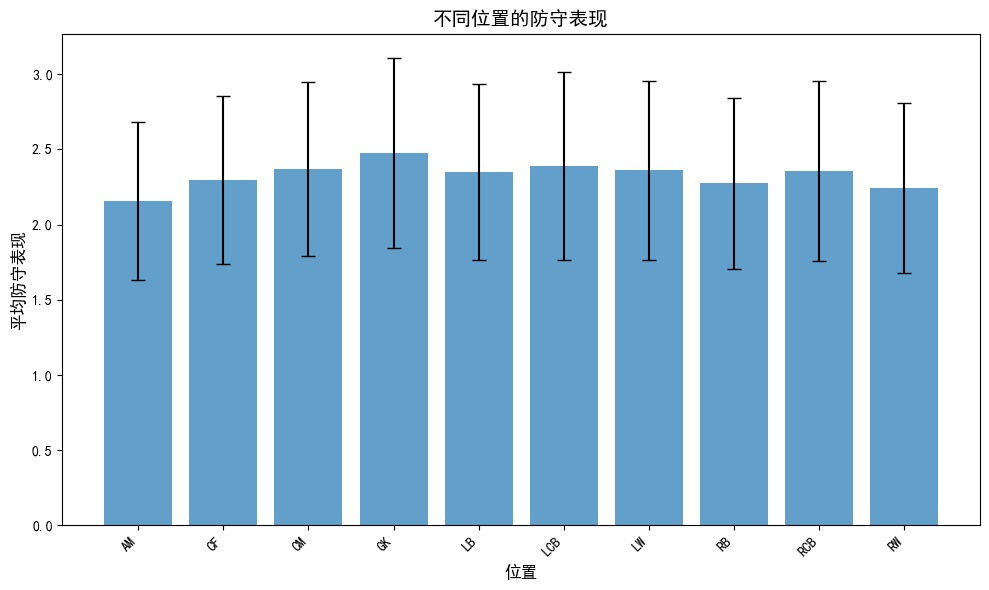


✓ 位置分析完成


In [11]:
if results_model1_df is not None:
    # 按位置统计
    position_stats = results_model1_df.drop_duplicates(subset=['Defender', 'graph_index']).groupby('defender_pos').agg({
        'Total_Perf': ['mean', 'std', 'count']
    }).round(4)
    
    position_stats.columns = ['_'.join(col).strip() for col in position_stats.columns.values]
    
    print("按位置统计防守表现:")
    print(position_stats)
    
    # 可视化
    fig, ax = plt.subplots(figsize=(10, 6))
    positions = position_stats.index
    means = position_stats['Total_Perf_mean']
    stds = position_stats['Total_Perf_std']
    
    ax.bar(positions, means, yerr=stds, capsize=5, alpha=0.7)
    ax.set_xlabel('位置', fontsize=12)
    ax.set_ylabel('平均防守表现', fontsize=12)
    ax.set_title('不同位置的防守表现', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print("\n✓ 位置分析完成")

## 11. 防守组合分析（中后卫配对）

In [12]:
if results_model1_df is not None:
    # 筛选中后卫
    cb_data = results_model1_df_unique[results_model1_df_unique['defender_pos'] == 'D']
    
    if len(cb_data) > 0:
        print(f"找到 {len(cb_data)} 条中后卫记录")
        print(f"中后卫球员: {cb_data['Defender'].unique()}")
        
        # 按图索引分组，找出同时出现的中后卫对
        cb_pairs = []
        for graph_idx in cb_data['graph_index'].unique():
            graph_cbs = cb_data[cb_data['graph_index'] == graph_idx]
            if len(graph_cbs) >= 2:
                defenders = sorted(graph_cbs['Defender'].tolist())
                total_perf = graph_cbs['Total_Perf'].sum()
                cb_pairs.append({
                    'graph_index': graph_idx,
                    'CB_Pair': ' + '.join(defenders[:2]),
                    'Summed_Total_Perf': total_perf
                })
        
        if cb_pairs:
            cb_duo_df = pd.DataFrame(cb_pairs)
            cb_duo_ranking = cb_duo_df.groupby('CB_Pair').agg({
                'Summed_Total_Perf': ['sum', 'mean', 'count']
            }).round(4)
            cb_duo_ranking.columns = ['_'.join(col).strip() for col in cb_duo_ranking.columns.values]
            cb_duo_ranking = cb_duo_ranking.sort_values('Summed_Total_Perf_sum', ascending=False)
            
            print("\n中后卫组合表现:")
            print(cb_duo_ranking)
        else:
            print("未找到中后卫配对")
    else:
        print("未找到中后卫数据")

未找到中后卫数据


## 12. 距离与影响力关系分析

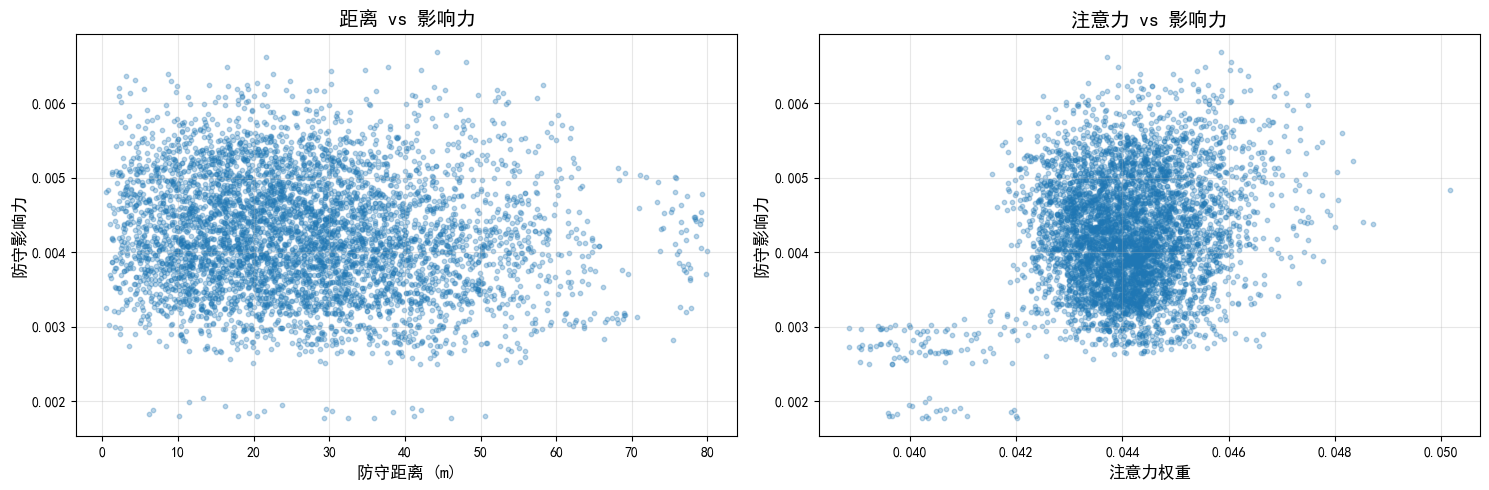


距离与影响力相关系数: -0.1059
注意力与影响力相关系数: 0.2155


In [13]:
if results_model1_df is not None:
    # 散点图：距离 vs 影响力
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # 距离 vs 影响力
    axes[0].scatter(results_model1_df['Def_Distance'], 
                   results_model1_df['Def_Influence'], 
                   alpha=0.3, s=10)
    axes[0].set_xlabel('防守距离 (m)', fontsize=12)
    axes[0].set_ylabel('防守影响力', fontsize=12)
    axes[0].set_title('距离 vs 影响力', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    
    # 注意力 vs 影响力
    axes[1].scatter(results_model1_df['Def_Attention'], 
                   results_model1_df['Def_Influence'], 
                   alpha=0.3, s=10)
    axes[1].set_xlabel('注意力权重', fontsize=12)
    axes[1].set_ylabel('防守影响力', fontsize=12)
    axes[1].set_title('注意力 vs 影响力', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 计算相关系数
    corr_dist = results_model1_df[['Def_Distance', 'Def_Influence']].corr().iloc[0, 1]
    corr_attn = results_model1_df[['Def_Attention', 'Def_Influence']].corr().iloc[0, 1]
    
    print(f"\n距离与影响力相关系数: {corr_dist:.4f}")
    print(f"注意力与影响力相关系数: {corr_attn:.4f}")

## 13. xT网格分析（可选）

In [14]:
# 加载xT网格
if os.path.exists(XT_GRID_PATH):
    xT_grid = pd.read_csv(XT_GRID_PATH, header=None)
    print(f"✓ 加载xT网格: {xT_grid.shape}")
    
    def get_pitch_value(data, x, y, pitch_length=105, pitch_width=68):
        """获取位置的xT值"""
        x = max(1, min(x, 104))
        y = max(1, min(y, 67))
        rows, cols = data.shape[0], data.shape[1]
        col_index = min(int(x / (pitch_length / cols)), cols - 1)
        row_index = min(int(y / (pitch_width / rows)), rows - 1)
        return data.iloc[row_index, col_index]
    
    # 可视化xT网格
    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(xT_grid, cmap='RdYlGn', aspect='auto', 
                   extent=[0, 105, 0, 68], origin='lower')
    plt.colorbar(im, ax=ax, label='xT值')
    ax.set_xlabel('X坐标 (m)', fontsize=12)
    ax.set_ylabel('Y坐标 (m)', fontsize=12)
    ax.set_title('Expected Threat (xT) 网格', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f"未找到xT网格文件: {XT_GRID_PATH}")

未找到xT网格文件: xT_grid.csv


## 总结

本notebook完成了以下测试：

✓ 数据加载（2022世界杯决赛）
✓ 球员评估结果分析
✓ 基本统计分析
✓ 网格区域分析
✓ 防守球员排名
✓ 位置分析
✓ 防守组合分析
✓ 相关性分析

### 下一步：

- 使用 `Experiments_2022WC.ipynb` 分析其他比赛
- 进行更深入的统计建模
- 比较不同比赛的防守策略

### 相关文件：

- `Experiments_2022WC.ipynb` - 通用实验分析工具
- `test_player_eval_final.ipynb` - 球员评估测试
- `PlayerEval_2022WC.ipynb` - 球员评估通用版本